## Using saved data to make real time retreiver

In [12]:
from Data.summaries import *

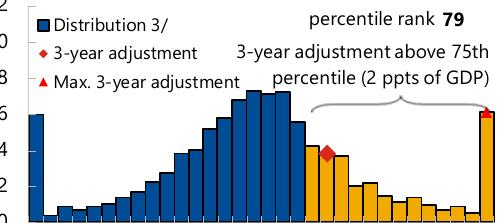

In [28]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images[89])

In [2]:
import json
from unstructured.staging.base import dict_to_elements

# Load JSON
with open("chunks.json", "r", encoding="utf-8") as f:
    chunks_dict = json.load(f)

# Convert back to elements
chunks = dict_to_elements(chunks_dict)


In [3]:
# We get 2 types of elements from the partition_pdf function
set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>"}

In [11]:
# separate tables from texts
tables = []
texts = []
# images = []

for chunk in chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)

    if "CompositeElement" in str(type((chunk))):
        texts.append(chunk)

# Get the images from the CompositeElement objects
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)

from unstructured.documents.elements import Table, CompositeElement

def get_tables(chunks):
    tables = []
    for chunk in chunks:
        if isinstance(chunk, CompositeElement):
            for el in chunk.metadata.orig_elements:
                if isinstance(el, Table):
                    tables.append(el)
    return tables
tables = get_tables(chunks)

In [13]:
print(len(texts))
print(len(tables))
print(len(images))

55
27
100


## Vector Stores

In [23]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [7]:
import uuid
from langchain_chroma import Chroma
from langchain_core.stores import InMemoryStore  
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever

# The vectorstore to use to index the child chunks
# vectorstore = Chroma(collection_name="multi_modal_rag", embedding_function=OpenAIEmbeddings())

# The storage layer for the parent documents
store = InMemoryStore()
id_key = "doc_id"

# # The retriever (empty to start)
# retriever = MultiVectorRetriever(
#     vectorstore=vectorstore,
#     docstore=store,
#     id_key=id_key,
#     persist_directory=r"C:\Users\dewan\Coding\MLOps\IAI_Solutions\chroma_IAI101_db"    
# )


In [14]:
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS

embeddings = OpenAIEmbeddings()

embedding_dim = len(embeddings.embed_query("hello world"))
index = faiss.IndexFlatL2(embedding_dim)

vectorstore = FAISS(
    embedding_function=OpenAIEmbeddings(),
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

# The retriever (empty to start)
retriever2 = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
    # persist_directory=r"C:\Users\dewan\Coding\MLOps\IAI_Solutions\FAISS_IAI_VS101"    
)


In [15]:
# Add texts
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=summary, metadata={id_key: doc_ids[i]}) for i, summary in enumerate(text_summaries)
]
retriever2.vectorstore.add_documents(summary_texts)
retriever2.docstore.mset(list(zip(doc_ids, texts)))
print("Documents added:", retriever2.vectorstore.index.ntotal)


# Add tables
table_ids = [str(uuid.uuid4()) for _ in tables]
summary_tables = [
    Document(page_content=summary, metadata={id_key: table_ids[i]}) for i, summary in enumerate(table_summaries)
]
retriever2.vectorstore.add_documents(summary_tables)
retriever2.docstore.mset(list(zip(table_ids, tables)))
print("Documents added:", retriever2.vectorstore.index.ntotal)


# Add image summaries
img_ids = [str(uuid.uuid4()) for _ in images]
summary_img = [
    Document(page_content=summary, metadata={id_key: img_ids[i]}) for i, summary in enumerate(image_summaries)
]
retriever2.vectorstore.add_documents(summary_img)
retriever2.docstore.mset(list(zip(img_ids, images)))
print("Documents added:", retriever2.vectorstore.index.ntotal)


Documents added: 55
Documents added: 82
Documents added: 182


In [16]:
print("Documents added:", retriever2.vectorstore.index.ntotal)


Documents added: 182


In [13]:
# Retrieve
docs = retriever2.invoke(
    "Qatar’s Diversification Progress and Challenges"
)

In [14]:
docs

In [16]:
for doc in docs:
    print(str(doc)+"\n"+ "-"*80)

30. Boosting Qatar’s economic complexity calls for (Text Figures 18 and 19):

e Fostering innovation. Qatar's patent applications rose rapidly over the last decade, more so than in its GCC peers. To promote innovation and support start-ups, a venture capital program ("Fund of Funds”) is being established by the QIA. NDS3 aims to increase Qatar's R&D funding from the current 0.7 percent of GDP to 1.5 percent, with the majority from the private sector. More attention is needed to enhance Qatar’s R&D spending efficiency and quality. Further improvement in intellectual property rights protection (e.g., in patent and trademark protection) is also key.

13 See Annex IX. “Promoting Gender Equality: Enhancing Women’s Workforce in Qatar” in the 2023 Staff Report for Qatar.

22 INTERNATIONAL MONETARY FUND

QATAR

e Promoting trade diversification. Progress in Qatar's export diversification is limited, mainly in services export (transportation and tourism). For a country with a small domestic mar

## RAG Pipeline

In [ ]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from base64 import b64decode
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


def parse_docs(docs):
    """Split base64-encoded images and texts"""
    b64 = []
    text = []
    for doc in docs:
        try:
            b64decode(doc)
            b64.append(doc)
        except Exception as e:
            text.append(doc)
    return {"images": b64, "texts": text}


def build_prompt(kwargs):

    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    context_text = ""
    if len(docs_by_type["texts"]) > 0:
        for text_element in docs_by_type["texts"]:
            context_text += text_element.text

    # construct prompt with context (including images)
    prompt_template = f"""
    Answer the question based only on the following context, which can include text, tables, and the below image.
    Context: {context_text}
    Question: {user_question}
    """

    prompt_content = [{"type": "text", "text": prompt_template}]

    if len(docs_by_type["images"]) > 0:
        for image in docs_by_type["images"]:
            prompt_content.append(
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/jpeg;base64,{image}"},
                }
            )

    return ChatPromptTemplate.from_messages(
        [
            HumanMessage(content=prompt_content),
        ]
    )


chain = (
    {
        "context": RunnableLambda(
            lambda q: cross_modal_rerank(q, retriever2.invoke(q))
        ) | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | ChatOpenAI(model="gpt-4o-mini")
    | StrOutputParser()
)

chain_with_sources = {
    "context": RunnableLambda(
        lambda q: cross_modal_rerank(q, retriever2.invoke(q))) | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | ChatOpenAI(model="gpt-4o-mini")
        | StrOutputParser()
    )
)

Response: Real non-hydro GDP growth in Qatar experienced fluctuations from 2016 to 2023. It showed a positive trend in 2016 and peaked in 2018, reflecting strong growth in non-hydrocarbon sectors. However, it faced declines in subsequent years, particularly in 2020, aligning with a downturn in overall GDP growth. By 2022, the growth remained modest, indicating weakness in non-hydrocarbon activities, and further slowed in 2023, although specific values are not provided in the context.


Context:
Figure 5. Qatar: Credit and Financial Sector Developments

Real private sector credit growth picked up since late 2023...

..While credit to the public sector remains the largest share of bank assets.

Bank Credit to Private Sector

(Percent, year on year)

Stock of Bank Domestic Credit by Borrower (Percent of total)

30 Real Nominal 20 10 12 #14 #16 #18 20 22 24

40 October 2024 e 30 e 2019 average 20 e 0 N ER efion x A) 2 £ ire] io) 2 iv) Real esta Consumption loans

Banks’ credit to non-hydro

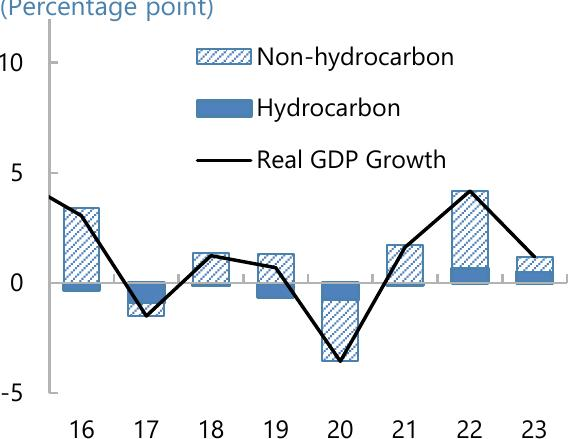

In [20]:
response = chain_with_sources.invoke(
    "What is Real Non-hydro GDP Growth?"
)

print("Response:", response['response'])

print("\n\nContext:")
for text in response['context']['texts']:
    print(text.text)
    print("Page number: ", text.metadata.page_number)
    print("\n" + "-"*50 + "\n")
for image in response['context']['images']:
    display_base64_image(image)

In [8]:
!pip show openai

Name: openai
Version: 2.8.0
Summary: The official Python library for the openai API
Home-page: https://github.com/openai/openai-python
Author: 
Author-email: OpenAI <support@openai.com>
License: Apache-2.0
Location: C:\ProgramData\anaconda3\envs\FreeGenAI\Lib\site-packages
Requires: anyio, distro, httpx, jiter, pydantic, sniffio, tqdm, typing-extensions
Required-by: crewai, instructor, langchain-openai


## Excellence track 

In [19]:
from libs.cross_modal_reranker import rerank_images

def cross_modal_rerank(query, docs):
    images = []
    texts = []

    for d in docs:
        if hasattr(d, "metadata") and hasattr(d.metadata, "image_base64"):
            images.append(d.metadata.image_base64)
        elif hasattr(d, "page_content") or hasattr(d, "text"):
            texts.append(d)

    # 🔥 REAL cross-modal reranking
    reranked_images = rerank_images(query, images)

    return {
        "texts": texts,
        "images": reranked_images   # list of {image, score}
    }


from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from base64 import b64decode
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


def parse_docs(docs):
    """Split base64-encoded images and texts"""
    b64 = []
    text = []
    for doc in docs:
        try:
            b64decode(doc)
            b64.append(doc)
        except Exception as e:
            text.append(doc)
    return {
        "texts": docs["texts"],
        "images": docs["images"]
    }


def build_prompt(kwargs):

    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    context_text = ""
    if len(docs_by_type["texts"]) > 0:
        for text_element in docs_by_type["texts"]:
            context_text += text_element.text

    # construct prompt with context (including images)
    prompt_template = f"""
    Answer the question based only on the following context, which can include text, tables, and the below image.
    Context: {context_text}
    Question: {user_question}
    """

    prompt_content = [{"type": "text", "text": prompt_template}]

    if len(docs_by_type["images"]) > 0:
        for image in docs_by_type["images"]:
            prompt_content.append(
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/jpeg;base64,{image}"},
                }
            )

    return ChatPromptTemplate.from_messages(
        [
            HumanMessage(content=prompt_content),
        ]
    )


chain = (
    {
        "context": RunnableLambda(
            lambda q: cross_modal_rerank(q, retriever2.invoke(q))
        ) | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | ChatOpenAI(model="gpt-4o-mini")
    | StrOutputParser()
)

chain_with_sources = {
    "context": RunnableLambda(
        lambda q: cross_modal_rerank(q, retriever2.invoke(q))) | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
}   | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | ChatOpenAI(model="gpt-4o-mini")
        | StrOutputParser()
    )
)




Response: Based on the provided context, the Real Non-hydro GDP Growth can be summarized as follows:

- **2021**: 2.8%
- **2022**: 5.7%
- **2023**: 1.1%
- **2024**: Projected at 1.9%
- **2025**: Projected at 2.1%

Overall trends suggest a decline in growth from 2021 to 2023, with a recovery expected in the subsequent years.


Context:
Figure 5. Qatar: Credit and Financial Sector Developments

Real private sector credit growth picked up since late 2023...

..While credit to the public sector remains the largest share of bank assets.

Bank Credit to Private Sector

(Percent, year on year)

Stock of Bank Domestic Credit by Borrower (Percent of total)

30 Real Nominal 20 10 12 #14 #16 #18 20 22 24

40 October 2024 e 30 e 2019 average 20 e 0 N ER efion x A) 2 £ ire] io) 2 iv) Real esta Consumption loans

Banks’ credit to non-hydro GDP gap is estimated to be negative in 2023.

Bank foreign liabilities remained elevated but moderating...

Credit to GDP Gap 1/

(Percentage point difference fro

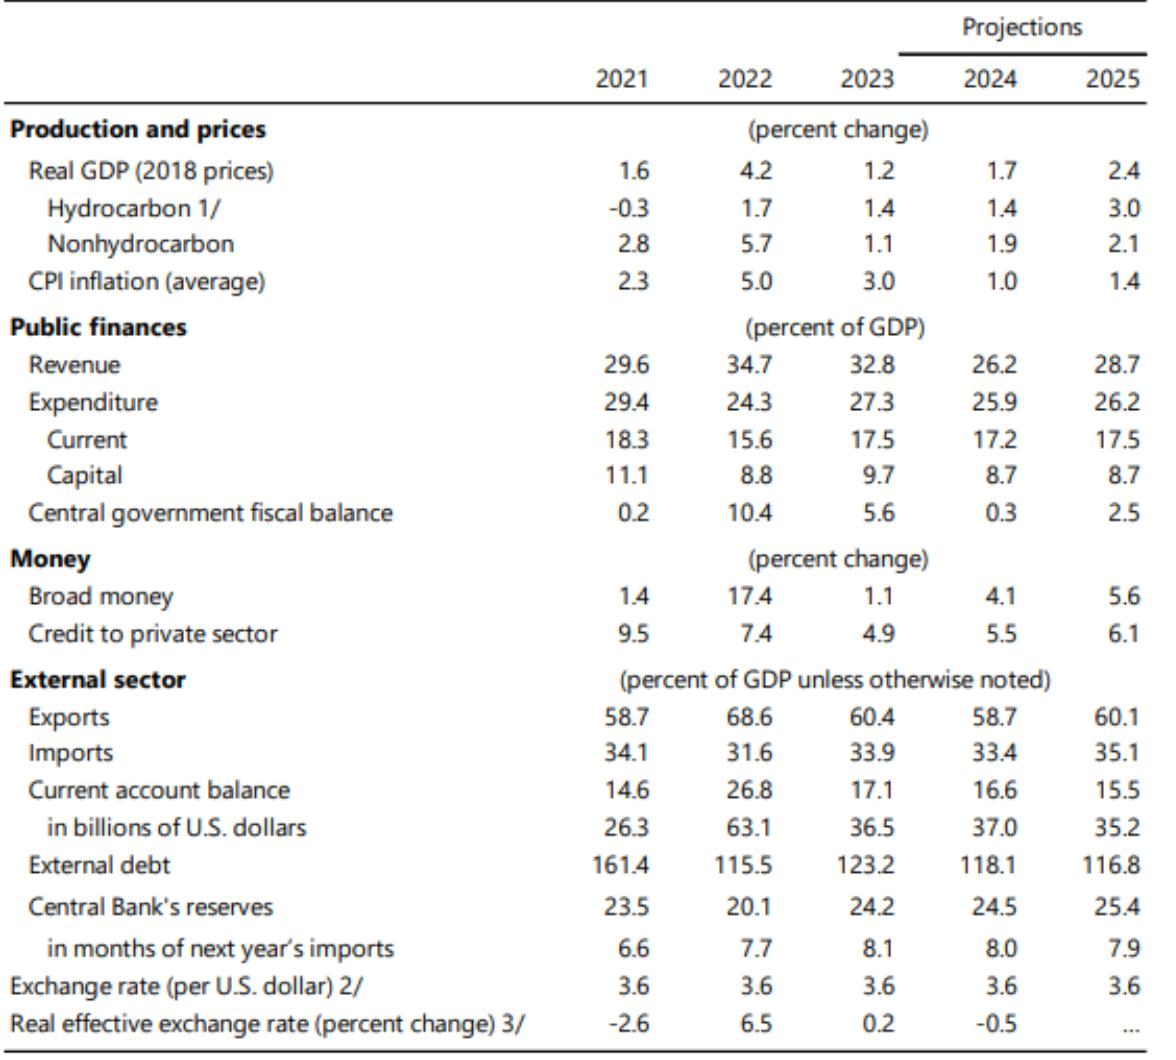

In [29]:
response = chain_with_sources.invoke(
    "What is Real Non-hydro GDP Growth?"
)

print("Response:", response['response'])

print("\n\nContext:")
for text in response['context']['texts']:
    print(text.text)
    print("Page number: ", text.metadata.page_number)
    print("\n" + "-"*50 + "\n")
for image in response['context']['images']:
    display_base64_image(image)

In [26]:
# from libs.vector_store_and_retreiver import retriever2, vectorstore
# from libs.image_function import display_base64_image
# from libs.connect import OPENAI_API_KEY
from libs.cross_modal_reranker import compute_image_similarity

import os
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from base64 import b64decode
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

import uuid
from langchain_core.stores import InMemoryStore  
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever

import os
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

store = InMemoryStore()
id_key = "doc_id"

def parse_docs(docs):
    images = []
    texts = []

    for d in docs:
        # Image/table element
        if (
            hasattr(d, "metadata")
            and hasattr(d.metadata, "image_base64")
            and d.metadata.image_base64
        ):
            images.append(d.metadata.image_base64)

        # Text document
        elif hasattr(d, "page_content"):
            texts.append(d)
        elif hasattr(d, "text"):
            texts.append(d)

    return {
        "images": images,
        "texts": texts
    }

def detect_mime_type(base64_str):
    """Detect MIME type from base64 string"""
    try:
        img_data = b64decode(base64_str)
        if img_data.startswith(b'\xff\xd8\xff'):
            return 'image/jpeg'
        elif img_data.startswith(b'\x89PNG'):
            return 'image/png'
        elif img_data.startswith(b'GIF'):
            return 'image/gif'
        else:
            return 'image/png'  # default
    except:
        return 'image/png'

def build_prompt(kwargs):
    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    context_text = ""
    if len(docs_by_type["texts"]) > 0:
        for text_element in docs_by_type["texts"]:
            # Handle both .text and .page_content attributes
            if hasattr(text_element, 'text'):
                context_text += text_element.text + "\n"
            elif hasattr(text_element, 'page_content'):
                context_text += text_element.page_content + "\n"

    # construct prompt with context (including images)
    prompt_template = f"""
    Answer the question in pointers based only on the following context, which can include text, tables, and the below image.
    Context: {context_text}
    Question: {user_question}
    """

    prompt_content = [{"type": "text", "text": prompt_template}]

    for image in docs_by_type.get("images", []):
        try:
            mime = detect_mime_type(image)
            prompt_content.append(
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:{mime};base64,{image}"
                    },
                }
            )
        except Exception:
            # corrupted / unsupported img
            continue

    return ChatPromptTemplate.from_messages(
        [
            HumanMessage(content=prompt_content),
        ]
    )

def cross_modal_rerank(query, docs, top_k=5):
    """
    Rerank documents based on their relevance to the query.
    For images: use CLIP similarity
    For text: use existing vector store similarity (already sorted by retriever)
    """
    scored_docs = []
    
    for d in docs:
        score = 0.0
        
        # Case 1: Document with image - use CLIP similarity
        if hasattr(d, "metadata") and hasattr(d.metadata, "image_base64") and d.metadata.image_base64:
            try:
                score = compute_image_similarity(query, d.metadata.image_base64)
            except Exception as e:
                print(f"Error computing image similarity: {e}")
                score = 0.0
        
        # Case 2: Text document - use vector store relevance score if available
        elif hasattr(d, "page_content") or hasattr(d, "text"):
            # If the retriever already provides scores, use them
            if hasattr(d, "metadata") and isinstance(d.metadata, dict) and "score" in d.metadata:
                score = d.metadata["score"]
            else:
                # Otherwise, assume documents from retriever are already sorted
                # and assign decreasing scores based on position
                score = 1.0  # Default high score for text documents
        
        scored_docs.append((score, d))
    
    # Sort by score in descending order
    scored_docs.sort(key=lambda x: x[0], reverse=True)
    
    # Return top_k documents
    reranked = [doc for score, doc in scored_docs[:top_k]]
    
    return reranked


chain = (
    {
        "context": RunnableLambda(
            lambda q: cross_modal_rerank(q, retriever2.invoke(q))
        ) | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | ChatOpenAI(model="gpt-4o-mini")
    | StrOutputParser()
)

chain_with_sources = {
    "context": RunnableLambda(
        lambda q: cross_modal_rerank(q, retriever2.invoke(q))) | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | ChatOpenAI(model="gpt-4o-mini")
        | StrOutputParser()
    )
)

## Excellence track 3

In [34]:
from libs.vector_store_and_retreiver import retriever2, vectorstore
from libs.image_function import display_base64_image
from libs.connect import OPENAI_API_KEY
from libs.cross_modal_reranker import compute_image_similarity
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from base64 import b64decode
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

import torch
import clip
import uuid
from langchain_core.stores import InMemoryStore  
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever

import os
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

store = InMemoryStore()
id_key = "doc_id"

def compute_text_similarity(query, text_content):
    """
    Compute similarity between query and text using CLIP text encoder.
    This allows cross-modal comparison.
    
    Args:
        query: The user's question/query string
        text_content: Text content to compare
    
    Returns:
        Cosine similarity score (float)
    """
    try:
        # Tokenize both texts
        query_input = clip.tokenize([query]).to(device)
        text_input = clip.tokenize([text_content[:77]]).to(device)  # CLIP has 77 token limit
        
        with torch.no_grad():
            query_features = clip_model.encode_text(query_input)
            text_features = clip_model.encode_text(text_input)
            
            # Normalize
            query_features = query_features / query_features.norm(dim=-1, keepdim=True)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        
        return torch.cosine_similarity(query_features, text_features).item()
    except Exception as e:
        print(f"Error computing text similarity: {e}")
        return 0.0

def parse_docs(docs):
    images = []
    texts = []

    for d in docs:
        # Image/table element
        if (
            hasattr(d, "metadata")
            and hasattr(d.metadata, "image_base64")
            and d.metadata.image_base64
        ):
            images.append(d.metadata.image_base64)

        # Text document
        elif hasattr(d, "page_content"):
            texts.append(d)
        elif hasattr(d, "text"):
            texts.append(d)

    return {
        "images": images,
        "texts": texts
    }

def detect_mime_type(base64_str):
    """Detect MIME type from base64 string"""
    try:
        img_data = b64decode(base64_str)
        if img_data.startswith(b'\xff\xd8\xff'):
            return 'image/jpeg'
        elif img_data.startswith(b'\x89PNG'):
            return 'image/png'
        elif img_data.startswith(b'GIF'):
            return 'image/gif'
        else:
            return 'image/png'  # default
    except:
        return 'image/png'

def build_prompt(kwargs):
    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    # Initialize context_text
    context_text = ""
    
    # Extract text from documents
    if docs_by_type.get("texts"):
        for text_element in docs_by_type["texts"]:
            # Handle both .text and .page_content attributes
            if hasattr(text_element, 'text'):
                context_text += text_element.text + "\n"
            elif hasattr(text_element, 'page_content'):
                context_text += text_element.page_content + "\n"
    
    # If no text context, add a note
    if not context_text.strip():
        context_text = "No text context available. Refer to images if provided."

    # Construct prompt with context (including images)
    prompt_template = f"""
    Answer the question in pointers based only on the following context, which can include text, tables, and the below image.
    Context: {context_text}
    Question: {user_question}
    """

    prompt_content = [{"type": "text", "text": prompt_template}]

    for image in docs_by_type.get("images", []):
        try:
            mime = detect_mime_type(image)
            prompt_content.append(
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:{mime};base64,{image}"
                    },
                }
            )
        except Exception:
            # corrupted / unsupported img
            continue

    return ChatPromptTemplate.from_messages(
        [
            HumanMessage(content=prompt_content),
        ]
    )

def cross_modal_rerank(query, docs, top_k=5):
    """
    Rerank documents based on their relevance to the query using CLIP embeddings.
    For images: use CLIP image-text similarity
    For text: use CLIP text-text similarity for true cross-modal comparison
    """
    scored_docs = []
    
    for idx, d in enumerate(docs):
        score = 0.0
        
        # Case 1: Document with image - use CLIP image-text similarity
        if hasattr(d, "metadata") and hasattr(d.metadata, "image_base64") and d.metadata.image_base64:
            try:
                score = compute_image_similarity(query, d.metadata.image_base64)
                print(f"Image doc {idx}: CLIP score = {score:.4f}")
            except Exception as e:
                print(f"Error computing image similarity: {e}")
                score = 0.0
        
        # Case 2: Text document - use CLIP text-text similarity
        elif hasattr(d, "page_content") or hasattr(d, "text"):
            text_content = d.page_content if hasattr(d, "page_content") else d.text
            
            # Use CLIP for text similarity (cross-modal reranking)
            try:
                score = compute_text_similarity(query, text_content)
                print(f"Text doc {idx}: CLIP score = {score:.4f}")
            except Exception as e:
                print(f"Error computing text similarity: {e}")
                # Fallback: check if retriever provided a score
                if hasattr(d, "metadata") and isinstance(d.metadata, dict) and "score" in d.metadata:
                    score = d.metadata["score"]
                else:
                    # Default score based on retriever position
                    score = 1.0 - (idx * 0.1)  # Decreasing score by position
        
        scored_docs.append((score, d))
    
    # Sort by score in descending order
    scored_docs.sort(key=lambda x: x[0], reverse=True)
    
    print(f"\n🔄 Reranked top {top_k} documents by relevance")
    for i, (score, doc) in enumerate(scored_docs[:top_k], 1):
        doc_type = "image" if (hasattr(doc, "metadata") and hasattr(doc.metadata, "image_base64")) else "text"
        print(f"  {i}. {doc_type.upper()} - score: {score:.4f}")
    
    # Return top_k documents
    reranked = [doc for score, doc in scored_docs[:top_k]]
    
    return reranked


chain = (
    {
        "context": RunnableLambda(
            lambda q: cross_modal_rerank(q, retriever2.invoke(q))
        ) | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | ChatOpenAI(model="gpt-4o-mini")
    | StrOutputParser()
)

chain_with_sources = {
    "context": RunnableLambda(
        lambda q: cross_modal_rerank(q, retriever2.invoke(q))
    ) | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | ChatOpenAI(model="gpt-4o-mini")
        | StrOutputParser()
    )
)

Error computing text similarity: name 'device' is not defined
Text doc 0: CLIP score = 0.0000
Image doc 1: CLIP score = 0.2889
Error computing text similarity: name 'device' is not defined
Text doc 3: CLIP score = 0.0000

🔄 Reranked top 5 documents by relevance
  1. IMAGE - score: 0.2889
  2. IMAGE - score: 0.0000
  3. TEXT - score: 0.0000
  4. IMAGE - score: 0.0000
Response: - **2021**: Non-hydrocarbon GDP growth was 2.8%.
- **2022**: Growth increased to 5.7%.
- **2023**: Growth estimated to decline to 1.1%.
- **2024**: Expected growth recovery to 1.9%.
- **2025**: Further growth projected at 2.1%.

This indicates a general trend of volatility in non-hydrocarbon GDP growth, with a peak in 2022 followed by a decline in 2023 and anticipated recovery in the subsequent years.


Context:
Figure 5. Qatar: Credit and Financial Sector Developments

Real private sector credit growth picked up since late 2023...

..While credit to the public sector remains the largest share of bank assets.

Ban

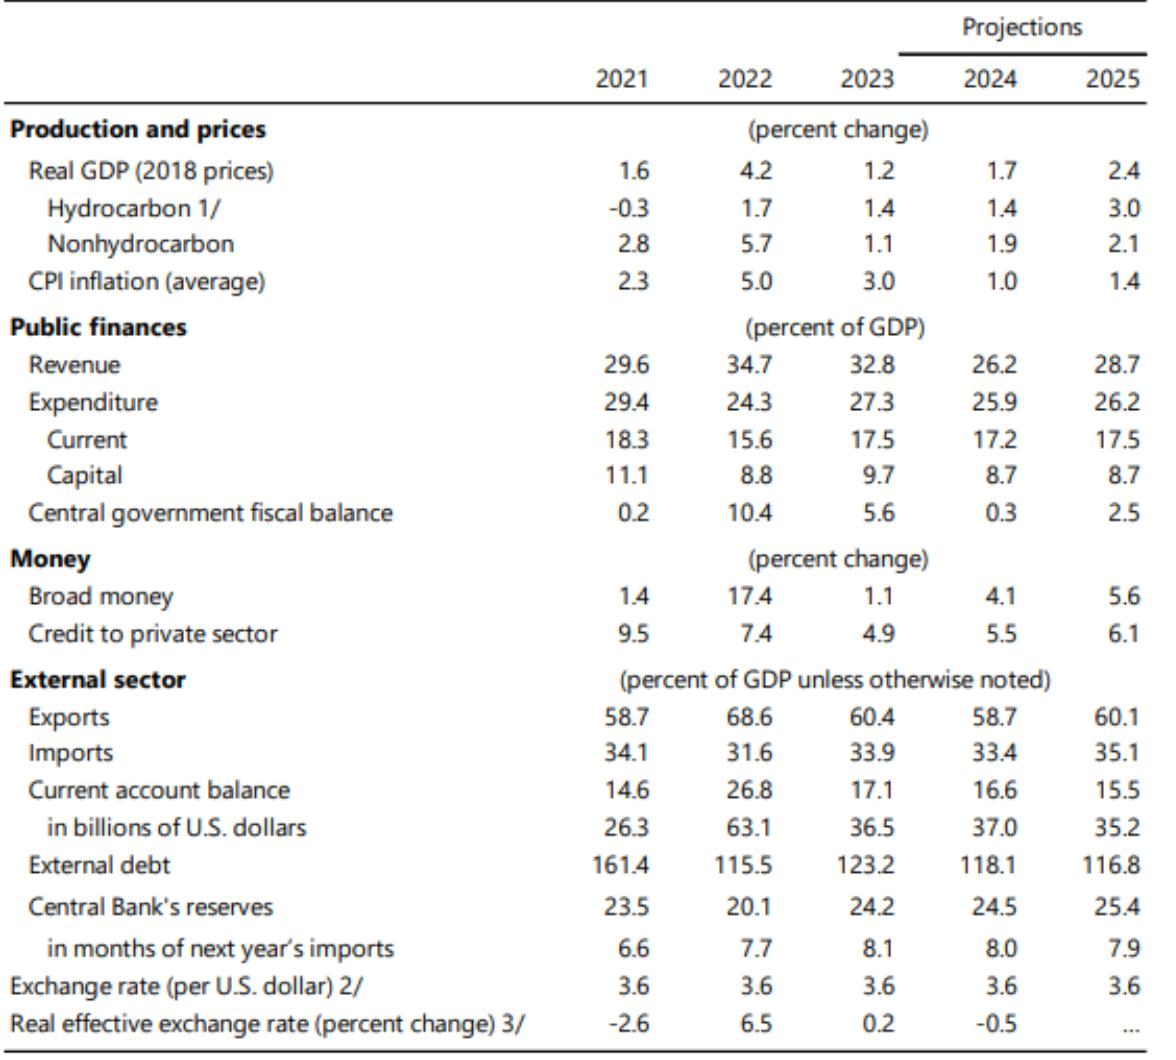

In [35]:
response = chain_with_sources.invoke(
    "What is Real Non-hydro GDP Growth?"
)

print("Response:", response['response'])

print("\n\nContext:")
for text in response['context']['texts']:
    print(text.text)
    print("Page number: ", text.metadata.page_number)
    print("\n" + "-"*50 + "\n")
for image in response['context']['images']:
    display_base64_image(image)